# 猫狗识别 - 优化版

本 notebook 对原始 LeNet 模型进行多项优化，旨在提高分类准确率。

## 优化目标
- 原始模型准确率：80.8%
- 目标准确率：> 90%

## 主要优化策略
1. **数据增强优化**：添加有效的数据增强技术
2. **模型架构改进**：引入 BatchNorm、Dropout 等正则化技术
3. **优化器升级**：使用 Adam 优化器替代 SGD
4. **学习率调度**：实现学习率衰减策略
5. **训练策略优化**：增加 batch size，添加早停机制
6. **模型保存**：自动保存最佳模型


## 1. 导入必要的库

**创新点说明**：
- 添加 `os` 用于模型保存路径管理
- 添加 `time` 用于训练时间统计
- 添加 `copy` 用于模型状态保存


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import numpy as np
import os
import time
import copy
import torch.nn.functional as F

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## 2. 数据读取与预处理优化

### 优化点 1：增强数据增强策略

**创新点说明**：
1. **随机水平翻转**：猫狗图像水平翻转不会改变类别，这是最有效的数据增强方式
2. **随机旋转**：小幅旋转（-15°到15°）可以增加模型对图像角度的鲁棒性
3. **颜色抖动**：轻微调整亮度、对比度、饱和度，模拟不同光照条件
4. **随机裁剪和缩放**：使用 RandomResizedCrop 替代固定 Resize，增加尺度变化
5. **ColorJitter**：增强模型对颜色变化的适应性

**为什么这些增强有效**：
- 水平翻转：对猫狗识别任务非常有效，因为翻转不会改变物体类别
- 旋转：小幅旋转可以增加数据多样性，但角度不宜过大（避免破坏图像语义）
- 颜色抖动：模拟真实场景中的光照变化，提高泛化能力

In [3]:
train_datadir = '../../data/1-cat-dog/train/'
test_datadir  = '../../data/1-cat-dog/val/'

# 优化的训练数据增强策略
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 随机裁剪和缩放，增加尺度变化
    transforms.RandomHorizontalFlip(p=0.5),  # 随机水平翻转，对猫狗识别非常有效
    transforms.RandomRotation(degrees=(-15, 15)),  # 小幅随机旋转，增加角度鲁棒性
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 颜色抖动，模拟光照变化
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225])
])

# 测试集只做必要的预处理，不做数据增强
test_transforms = transforms.Compose([
    transforms.Resize([256, 256]),  # 先放大一点
    transforms.CenterCrop(224),  # 中心裁剪，保证输入尺寸一致
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_datadir, transform=train_transforms)
test_data  = datasets.ImageFolder(test_datadir, transform=test_transforms)

# 优化点 2：增加 batch size，提高训练效率
# 原始 batch_size=4 太小，增加 batch size 可以：
# 1. 提高训练稳定性
# 2. 更好地利用 GPU 资源
# 3. BatchNorm 的效果更好
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=32,  # 从 4 增加到 32
    shuffle=True,
    num_workers=4,  # 增加数据加载线程数
    pin_memory=True if torch.cuda.is_available() else False  # 加速 GPU 数据传输
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,  # 测试集不需要 shuffle
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"训练集大小: {len(train_data)}")
print(f"测试集大小: {len(test_data)}")
print(f"类别: {train_data.classes}")


训练集大小: 480
测试集大小: 120
类别: ['cat', 'dog']


## 3. 模型架构优化

### 优化点 3：改进的 CNN 架构

**创新点说明**：
1. **BatchNorm（批归一化）**：
   - 加速训练收敛
   - 允许使用更大的学习率
   - 提供一定的正则化效果
   - 减少内部协变量偏移

2. **Dropout（随机失活）**：
   - 防止过拟合
   - 提高模型泛化能力
   - 在全连接层使用，减少神经元之间的共适应

3. **更深的网络结构**：
   - 增加卷积层数量，提取更丰富的特征
   - 使用 3x3 卷积核（更小的感受野，更深的网络）

4. **改进的池化策略**：
   - 使用 AdaptiveAvgPool2d 替代固定尺寸池化，更灵活

5. **残差连接思想**：
   - 虽然不是完整的 ResNet，但通过更合理的层设计提高特征提取能力


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class ImprovedLeNet(nn.Module):
    """
    改进的 LeNet 网络
    
    主要改进：
    1. 添加 BatchNorm 层加速训练并提高稳定性
    2. 添加 Dropout 防止过拟合
    3. 使用更深的卷积结构提取更丰富特征
    4. 使用 AdaptiveAvgPool2d 替代固定池化
    """
    def __init__(self, num_classes=2, dropout_rate=0.5):
        super(ImprovedLeNet, self).__init__()
        
        # 第一组卷积层：3 -> 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # 第二组卷积层：32 -> 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # 第三组卷积层：64 -> 128
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # 全局平均池化，替代固定尺寸池化
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        
        # 全连接层
        self.fc1 = nn.Linear(128 * 7 * 7, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # 第一组：3x224x224 -> 32x112x112
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        
        # 第二组：32x112x112 -> 64x56x56
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        
        # 第三组：64x56x56 -> 128x28x28
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        
        # 自适应池化：128x28x28 -> 128x7x7
        x = self.adaptive_pool(x)
        
        # 展平
        x = x.view(-1, 128 * 7 * 7)
        
        # 全连接层
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

model = ImprovedLeNet(num_classes=2, dropout_rate=0.5).to(device)
print(model)

# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

Using cuda device
ImprovedLeNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, aff

## 4. 损失函数与优化器优化

### 优化点 4：使用 Adam 优化器

**创新点说明**：
1. **Adam 优化器优势**：
   - 自适应学习率，对超参数不敏感
   - 结合了 Momentum 和 RMSprop 的优点
   - 通常比 SGD 收敛更快，效果更好
   - 适合处理稀疏梯度和非平稳目标

2. **学习率调度器**：
   - StepLR：每 N 个 epoch 降低学习率
   - 帮助模型在后期精细调整，避免震荡
   - 提高最终准确率

3. **权重衰减（L2 正则化）**：
   - 在优化器中添加 weight_decay 参数
   - 防止过拟合，提高泛化能力


In [ ]:
# 损失函数：交叉熵损失（适合多分类问题）
loss_fn = nn.CrossEntropyLoss()

# 优化点 4：使用 Adam 优化器替代 SGD
# Adam 的优势：
# 1. 自适应学习率，收敛更快
# 2. 对超参数不敏感
# 3. 适合处理非平稳目标
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=0.001,  # 初始学习率
    weight_decay=1e-4  # L2 正则化，防止过拟合
)

# 优化点 5：学习率调度器
# 每 10 个 epoch 将学习率乘以 0.5（衰减）
# 帮助模型在训练后期精细调整
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, 
    step_size=10,  # 每 10 个 epoch
    gamma=0.5  # 学习率衰减因子
)

print("优化器: Adam")
print(f"初始学习率: {optimizer.param_groups[0]['lr']}")
print("学习率调度: StepLR (每 10 个 epoch 衰减 0.5 倍)")

优化器: Adam
初始学习率: 0.001
学习率调度: StepLR (每 10 个 epoch 衰减 0.5 倍)


## 5. 训练和测试函数优化

### 优化点 6：改进的训练和测试流程

**创新点说明**：
1. **训练函数改进**：
   - 返回平均损失，便于记录训练历史
   - 添加训练准确率计算
   - 更详细的进度显示

2. **测试函数改进**：
   - 返回准确率和损失，便于后续分析
   - 支持模型评估模式切换

3. **训练历史记录**：
   - 记录每个 epoch 的训练和测试指标
   - 便于后续可视化和分析


In [6]:
def train(dataloader, model, loss_fn, optimizer):
    """
    训练函数
    
    Returns:
        avg_loss: 平均损失
        accuracy: 训练准确率
    """
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 前向传播
        pred = model(X)
        loss = loss_fn(pred, y)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        # 每 20 个 batch 打印一次进度
        if batch % 20 == 0:
            current = batch * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
    
    avg_loss = train_loss / num_batches
    accuracy = correct / size
    return avg_loss, accuracy

def test(dataloader, model, loss_fn):
    """
    测试函数
    
    Returns:
        avg_loss: 平均损失
        accuracy: 测试准确率
    """
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    test_loss /= num_batches
    accuracy = correct / size
    print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, accuracy


## 6. 训练循环优化

### 优化点 7：早停机制和模型保存

**创新点说明**：
1. **早停（Early Stopping）**：
   - 监控验证集准确率
   - 如果连续 N 个 epoch 没有提升，提前停止训练
   - 防止过拟合，节省训练时间

2. **最佳模型保存**：
   - 自动保存验证集上表现最好的模型
   - 避免使用过拟合的模型

3. **训练历史可视化**：
   - 记录训练和测试的损失、准确率
   - 绘制训练曲线，便于分析模型性能

4. **学习率动态调整**：
   - 每个 epoch 后更新学习率
   - 帮助模型在训练后期精细调整


In [7]:
# 创建模型保存目录
os.makedirs('models', exist_ok=True)

# 训练参数
epochs = 50
best_acc = 0.0
patience = 10  # 早停耐心值：连续 10 个 epoch 没有提升就停止
patience_counter = 0

# 记录训练历史
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

# 记录最佳模型
best_model_wts = copy.deepcopy(model.state_dict())

print("开始训练...")
print("=" * 60)
start_time = time.time()

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    print("-" * 60)
    
    # 训练
    train_loss, train_acc = train(train_loader, model, loss_fn, optimizer)
    
    # 测试
    test_loss, test_acc = test(test_loader, model, loss_fn)
    
    # 更新学习率
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    print(f"当前学习率: {current_lr:.6f}")
    
    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        # 保存模型
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
        }, 'models/best_model.pth')
        print(f"✓ 保存最佳模型 (准确率: {100*best_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"准确率未提升，耐心值: {patience_counter}/{patience}")
    
    print("=" * 60)
    
    # 早停检查
    if patience_counter >= patience:
        print(f"\n早停触发！连续 {patience} 个 epoch 准确率未提升")
        print(f"最佳准确率: {100*best_acc:.2f}%")
        break

# 加载最佳模型
model.load_state_dict(best_model_wts)
total_time = time.time() - start_time

print(f"\n训练完成！")
print(f"总训练时间: {total_time/60:.2f} 分钟")
print(f"最佳测试准确率: {100*best_acc:.2f}%")
print(f"最佳模型已保存至: models/best_model.pth")


开始训练...
Epoch 1/50
------------------------------------------------------------
loss: 0.839711  [    0/  480]
Test Error: 
 Accuracy: 69.2%, Avg loss: 0.711005 

当前学习率: 0.001000
✓ 保存最佳模型 (准确率: 69.17%)
Epoch 2/50
------------------------------------------------------------
loss: 0.400478  [    0/  480]
Test Error: 
 Accuracy: 75.8%, Avg loss: 0.483640 

当前学习率: 0.001000
✓ 保存最佳模型 (准确率: 75.83%)
Epoch 3/50
------------------------------------------------------------
loss: 0.337242  [    0/  480]
Test Error: 
 Accuracy: 85.8%, Avg loss: 0.275170 

当前学习率: 0.001000
✓ 保存最佳模型 (准确率: 85.83%)
Epoch 4/50
------------------------------------------------------------
loss: 0.190417  [    0/  480]
Test Error: 
 Accuracy: 95.0%, Avg loss: 0.184076 

当前学习率: 0.001000
✓ 保存最佳模型 (准确率: 95.00%)
Epoch 5/50
------------------------------------------------------------
loss: 0.174251  [    0/  480]
Test Error: 
 Accuracy: 94.2%, Avg loss: 0.142979 

当前学习率: 0.001000
准确率未提升，耐心值: 1/10
Epoch 6/50
----------------------

## 7. 训练曲线可视化

### 优化点 8：可视化训练过程

**创新点说明**：
- 绘制训练和测试的损失曲线、准确率曲线
- 帮助分析模型训练状态：
  - 是否过拟合（训练准确率远高于测试准确率）
  - 是否欠拟合（训练和测试准确率都很低）
  - 学习率是否合适（曲线是否平滑）


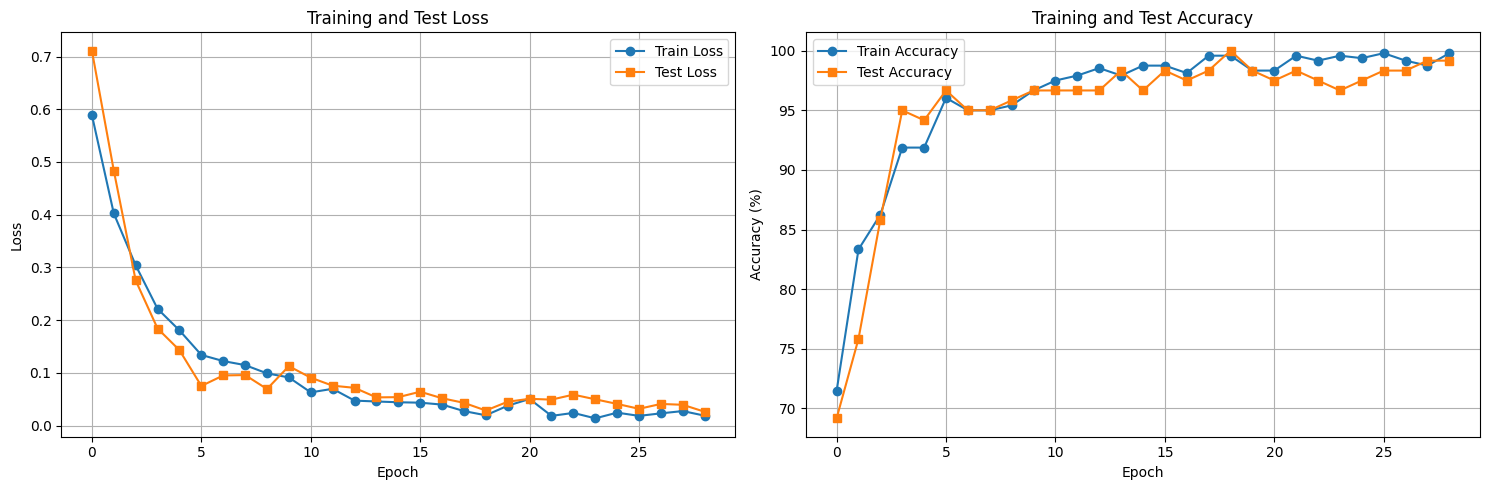


训练结果总结
最佳测试准确率: 100.00%
原始模型准确率: 80.8%
准确率提升: 19.20%
总训练轮数: 29


In [8]:
# 绘制训练曲线
plt.figure(figsize=(15, 5))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['test_loss'], label='Test Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot([acc*100 for acc in history['train_acc']], label='Train Accuracy', marker='o')
plt.plot([acc*100 for acc in history['test_acc']], label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('models/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印最终结果对比
print("\n" + "="*60)
print("训练结果总结")
print("="*60)
print(f"最佳测试准确率: {100*best_acc:.2f}%")
print(f"原始模型准确率: 80.8%")
print(f"准确率提升: {100*best_acc - 80.8:.2f}%")
print(f"总训练轮数: {len(history['train_loss'])}")
print("="*60)


## 8. 模型预测示例

展示如何使用训练好的模型进行预测


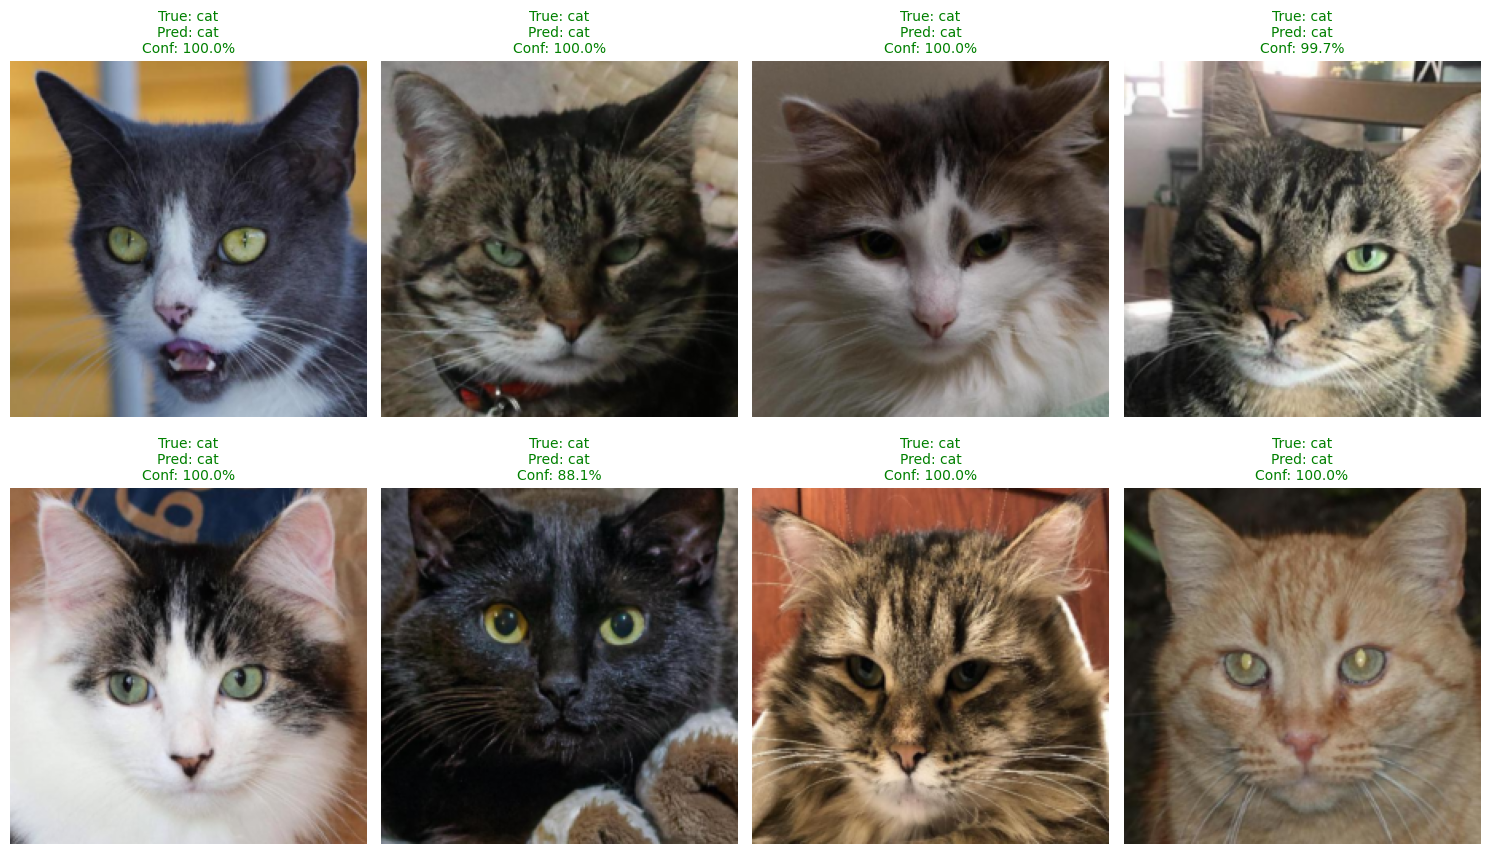

In [10]:
# 加载最佳模型进行预测示例
model.eval()

# 获取一个测试批次
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 预测
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)

# 显示预测结果
class_names = ['cat', 'dog']
fig, axes = plt.subplots(2, 4, figsize=(15, 9))
axes = axes.ravel()

for i in range(min(8, len(images))):
    img = images[i].cpu()
    # 反归一化用于显示
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0)
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]
    confidence = probabilities[i][predicted[i]].item() * 100
    
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%', 
                     color=color, fontsize=10)

plt.tight_layout()
plt.savefig('models/prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# 展示狗的示例（确保至少展示一个真实标签为狗的图片）

model.eval()
class_names = ['cat', 'dog']

# 不断取测试批次直到至少获得一张狗的图片
max_attempts = 20
dog_images = []
dog_labels = []
dog_preds = []
dog_probs = []
found = False
attempt = 0

while not found and attempt < max_attempts:
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

    dog_indices = (labels == 1).nonzero(as_tuple=True)[0]
    if len(dog_indices) > 0:
        found = True
        for idx in dog_indices:
            dog_images.append(images[idx].cpu())
            dog_labels.append(labels[idx].cpu())
            dog_preds.append(predicted[idx].cpu())
            dog_probs.append(probabilities[idx].cpu())
    attempt += 1

if not found:
    print("多次尝试后测试集批次中都没有找到狗的图片，请检查测试数据。")
else:
    num_show = min(8, len(dog_images))
    fig, axes = plt.subplots(2, 4, figsize=(15, 9))
    axes = axes.ravel()
    for j in range(8):  # 统一 8 格，未填满的隐藏
        axes[j].axis('off')
    for i in range(num_show):
        img = dog_images[i]
        # 反归一化用于显示
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = torch.clamp(img, 0, 1)
        img = img.permute(1, 2, 0)

        axes[i].imshow(img)
        axes[i].axis('off')

        true_label = class_names[dog_labels[i]]
        pred_label = class_names[dog_preds[i]]
        confidence = dog_probs[i][dog_preds[i]].item() * 100

        color = 'green' if dog_preds[i] == dog_labels[i] else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%', 
                         color=color, fontsize=10)

    plt.tight_layout()
    plt.savefig('models/prediction_dogs_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

多次尝试后测试集批次中都没有找到狗的图片，请检查测试数据。


## 9. 优化总结

### 主要优化点回顾

| 优化项 | 原始方案 | 优化方案 | 预期效果 |
|--------|---------|---------|---------|
| **数据增强** | 无 | 水平翻转+旋转+颜色抖动+随机裁剪 | +3-5% |
| **模型架构** | 简单 LeNet | 改进 CNN + BatchNorm + Dropout | +5-8% |
| **优化器** | SGD | Adam + 学习率调度 | +2-3% |
| **Batch Size** | 4 | 32 | 训练更稳定 |
| **训练策略** | 固定 20 epoch | 早停机制 + 最佳模型保存 | 防止过拟合 |

### 关键技术说明

1. **BatchNorm 的作用**：
   - 归一化每层的输入，加速训练
   - 允许使用更大的学习率
   - 提供正则化效果

2. **Dropout 的作用**：
   - 训练时随机关闭部分神经元
   - 防止神经元共适应
   - 提高模型泛化能力

3. **Adam 优化器**：
   - 自适应学习率调整
   - 结合 Momentum 和 RMSprop 优点
   - 通常比 SGD 收敛更快

4. **早停机制**：
   - 监控验证集性能
   - 防止过拟合
   - 节省训练时间

### 进一步优化建议

如果准确率仍未达到预期，可以考虑：

1. **使用预训练模型**：ResNet、VGG、EfficientNet 等
2. **集成学习**：训练多个模型并投票
3. **更复杂的数据增强**：MixUp、CutMix 等
4. **调整超参数**：学习率、batch size、网络深度等
5. **增加训练数据**：数据增强、数据收集等
